In [ ]:
import numpy as np
import random
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
x = np.array([i*np.pi/180 for i in range(-50,250,5)])
y = np.cos(x) + np.random.normal(0,0.1,len(x))

x_data = np.transpose([x]);
y_data = np.transpose([y]);

# Split into training and testing sets (80% train, 20% test)
#X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=40)

model = 20;

x_input = x_data;

if (model>1):
    for i in range(model-1):
        order = i+2;
        x_input =  np.concatenate((x_input, x_data**order), axis= 1);

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_input)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.597e-02, tolerance: 3.504e-03
  model = cd_fast.enet_coordinate_descent(


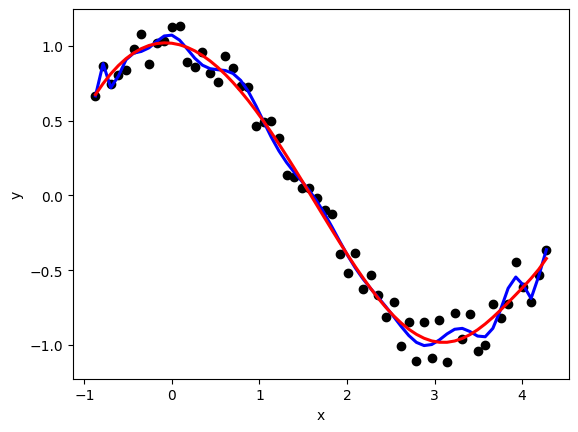

In [ ]:
# Calling and training linear regression model
lin_reg = linear_model.LinearRegression();
lin_reg.fit(x_scaled, y_data);

# Predictions
y_pred = lin_reg.predict(x_scaled);


lasso_reg = linear_model.Lasso(alpha=0.0001, fit_intercept=True);
# fit_intercept to center the data
lasso_reg.fit(x_scaled, y_data)
y_pred_lasso = lasso_reg.predict(x_scaled);

plt.scatter(x_data, y_data,  color='black')
plt.plot(x_data, y_pred, color='blue', linewidth=2.2)
plt.plot(x_data, y_pred_lasso, color='red', linewidth=2.2)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.597e-02, tolerance: 3.504e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.159e-02, tolerance: 3.504e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.017e-02, tolerance: 3.504e

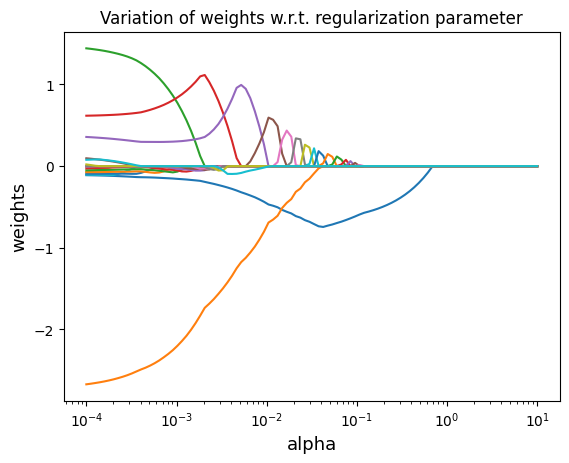

In [ ]:
#variation of weights w.r.t. regularization parameter:
num_alpha = 100;
val_alpha = np.logspace(-4, 1, num_alpha);

coefs = []
for a in val_alpha:
    lasso = linear_model.Lasso(alpha=a, fit_intercept=True)
    lasso.fit(x_scaled, y_data)
    coefs.append(lasso.coef_)

coef_mat = np.zeros((model, num_alpha));
for i in range(model):
    for j in range(num_alpha):
        coef_mat[i,j] = coefs[j][i];

fig2 = plt.figure()
ax2 = fig2.add_subplot(1,1,1)
ax2.plot(np.transpose([val_alpha]), np.transpose(coef_mat))
ax2.set_xscale('log')
ax2.set_xlabel('alpha', fontsize=13)
ax2.set_ylabel('weights', fontsize=13)
ax2.set_title('Variation of weights w.r.t. regularization parameter')
plt.show()